In [1]:
import numpy as np
import pandas as pd
import joblib
from pathlib import Path

# Project directories
processed_dir = Path("../data/processed")
models_dir = Path("../models")

# Load test data
X_test = np.load(processed_dir / "X_test_scaled.npy")
y_test = np.load(processed_dir / "y_test.npy")

# Load models
xgb_model = joblib.load(models_dir / "xgboost_baseline.joblib")
final_model = joblib.load(
    models_dir / "final_xgboost_intrusion_detector.joblib"
)

# Load deployment configuration
config = joblib.load(
    models_dir / "deployment_config.joblib"
)

print("Files loaded successfully!")
print()
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("Decision threshold:", config["threshold"])
print("Input features:", config["input_features"])

Files loaded successfully!

X_test: (82332, 194)
y_test: (82332,)
Decision threshold: 0.5
Input features: 194


In [2]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Baseline XGBoost predictions
baseline_pred = xgb_model.predict(X_test)
baseline_prob = xgb_model.predict_proba(X_test)[:, 1]

# Final XGBoost predictions
final_prob = final_model.predict_proba(X_test)[:, 1]

threshold = config["threshold"]

final_pred = (
    final_prob >= threshold
).astype(int)

# Calculate baseline metrics
baseline_metrics = {
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred),
    "Recall": recall_score(y_test, baseline_pred),
    "F1 Score": f1_score(y_test, baseline_pred),
    "ROC-AUC": roc_auc_score(y_test, baseline_prob)
}

# Calculate final model metrics
final_metrics = {
    "Accuracy": accuracy_score(y_test, final_pred),
    "Precision": precision_score(y_test, final_pred),
    "Recall": recall_score(y_test, final_pred),
    "F1 Score": f1_score(y_test, final_pred),
    "ROC-AUC": roc_auc_score(y_test, final_prob)
}

print("Baseline XGBoost:")
for metric, value in baseline_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nFinal XGBoost:")
for metric, value in final_metrics.items():
    print(f"{metric}: {value:.4f}")

Baseline XGBoost:
Accuracy: 0.8730
Precision: 0.8218
Recall: 0.9823
F1 Score: 0.8949
ROC-AUC: 0.9831

Final XGBoost:
Accuracy: 0.8730
Precision: 0.8218
Recall: 0.9823
F1 Score: 0.8949
ROC-AUC: 0.9831


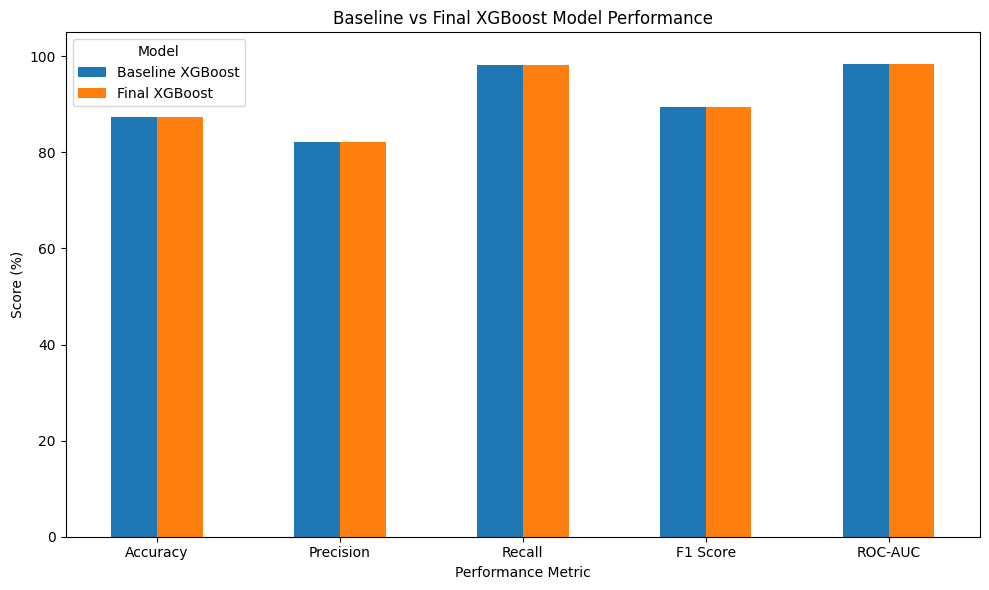

In [3]:
import matplotlib.pyplot as plt

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    "Baseline XGBoost": baseline_metrics,
    "Final XGBoost": final_metrics
})

# Convert to percentages
comparison_percent = comparison_df * 100

# Create bar chart
ax = comparison_percent.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline vs Final XGBoost Model Performance")
plt.ylabel("Score (%)")
plt.xlabel("Performance Metric")
plt.ylim(0, 105)

plt.xticks(rotation=0)

plt.legend(title="Model")

plt.tight_layout()
plt.show()

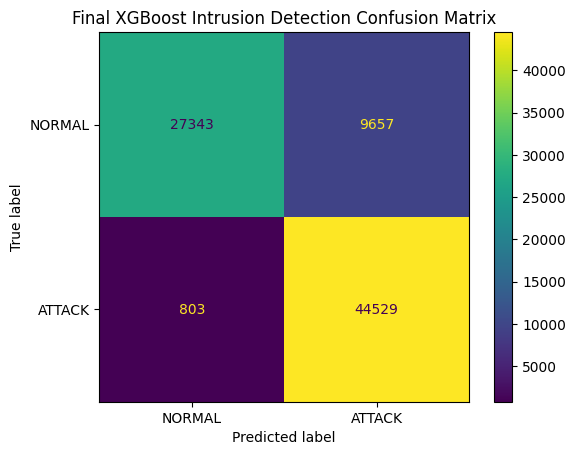

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions using the final model
final_prob = final_model.predict_proba(X_test)[:, 1]

threshold = config["threshold"]

final_pred = (final_prob >= threshold).astype(int)

# Create confusion matrix
cm = confusion_matrix(y_test, final_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "ATTACK"]
)

disp.plot()

plt.title("Final XGBoost Intrusion Detection Confusion Matrix")
plt.show()

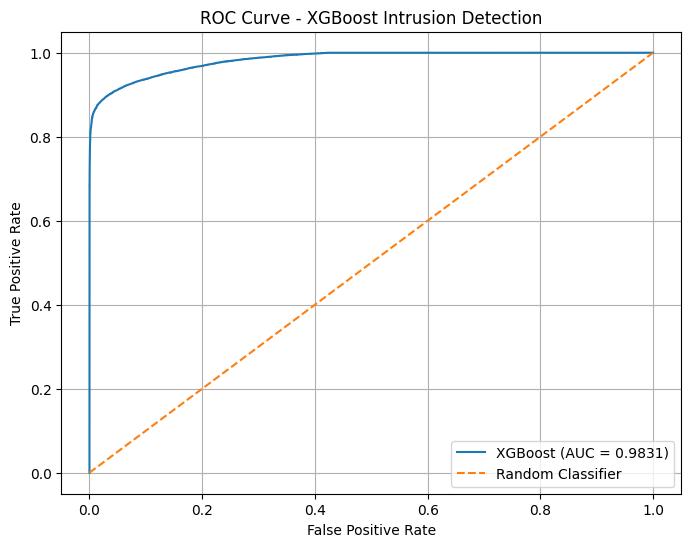

In [5]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, final_prob)

# Calculate ROC-AUC
auc_score = roc_auc_score(y_test, final_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {auc_score:.4f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost Intrusion Detection")
plt.legend()
plt.grid()

plt.show()

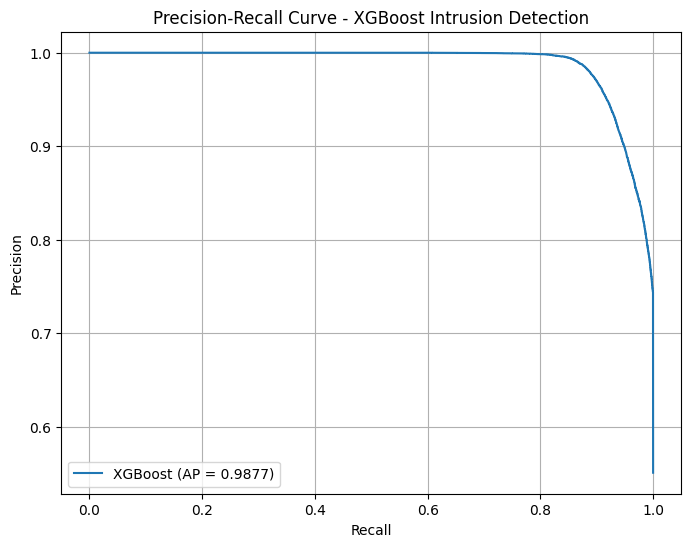

In [6]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Calculate precision-recall curve
precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    final_prob
)

# Calculate average precision
avg_precision = average_precision_score(
    y_test,
    final_prob
)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"XGBoost (AP = {avg_precision:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost Intrusion Detection")

plt.legend()
plt.grid()

plt.show()

In [7]:
# Get feature names from the saved preprocessor
preprocessor = joblib.load(
    processed_dir / "preprocessor.joblib"
)

feature_names = preprocessor.get_feature_names_out()

# Get feature importance values
importance_values = final_model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

# Select top 20
top_features = feature_importance.head(20)

top_features

,Feature,Importance
193,remainder__is_sm_ips_ports,0.534868
161,remainder__sttl,0.203741
183,remainder__ct_state_ttl,0.132614
162,remainder__dttl,0.023697
186,remainder__ct_dst_sport_ltm,0.006843
171,remainder__swin,0.006142
192,remainder__ct_srv_dst,0.005798
120,cat__proto_unas,0.005768
97,cat__proto_sctp,0.004796
135,cat__service_dns,0.004636


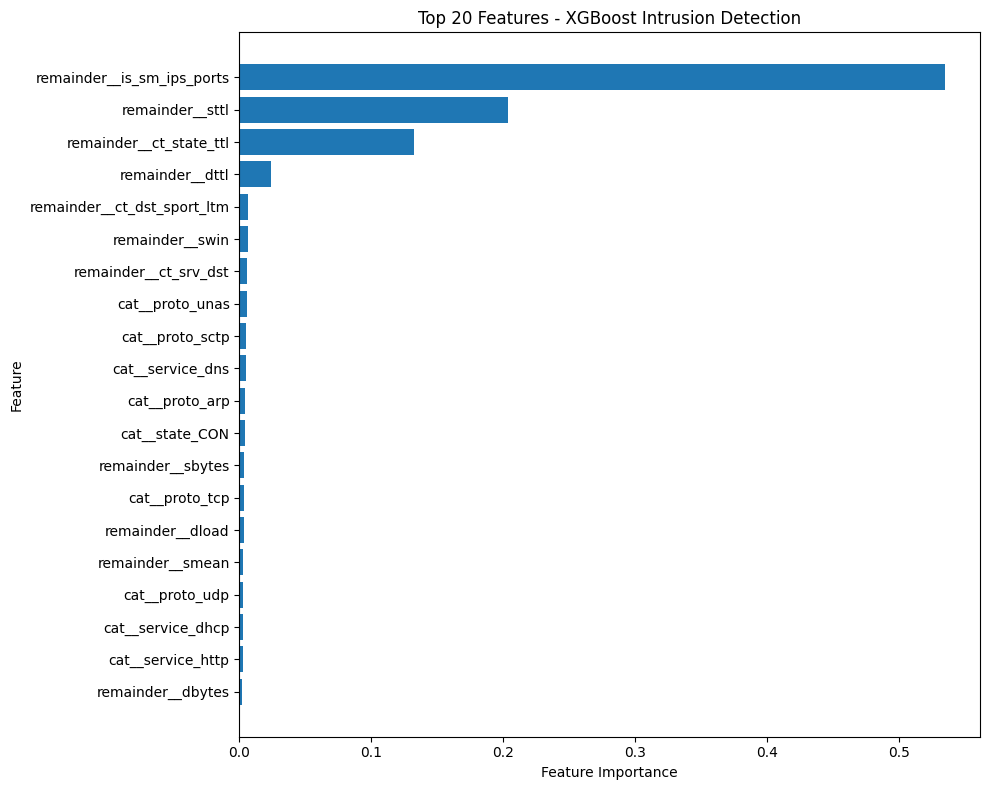

In [8]:
import matplotlib.pyplot as plt

# Sort top features for horizontal plotting
plot_features = top_features.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_features["Feature"],
    plot_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features - XGBoost Intrusion Detection")

plt.tight_layout()
plt.show()

In [9]:
# Load the original testing dataset
raw_test_path = Path("../data/raw/UNSW_NB15_testing-set.csv")
raw_test_df = pd.read_csv(raw_test_path)

# Add model predictions to the raw test data
raw_test_df["prediction"] = final_pred

# Select only actual attacks
attack_results = raw_test_df[
    raw_test_df["label"] == 1
].copy()

# Calculate detection rate for each attack category
attack_detection = (
    attack_results
    .groupby("attack_cat")["prediction"]
    .agg(["count", "sum"])
)

attack_detection.columns = ["Total", "Detected"]

attack_detection["Missed"] = (
    attack_detection["Total"] -
    attack_detection["Detected"]
)

attack_detection["Detection_Rate"] = (
    attack_detection["Detected"] /
    attack_detection["Total"] * 100
)

attack_detection = attack_detection.sort_values(
    "Detection_Rate",
    ascending=False
)

attack_detection.round(2)

,Total,Detected,Missed,Detection_Rate
attack_cat,,,,
Backdoor,583,583,0,100.00
Worms,44,44,0,100.00
Generic,18871,18870,1,99.99
DoS,4089,4087,2,99.95
Reconnaissance,3496,3493,3,99.91
Exploits,11132,11069,63,99.43
Shellcode,378,374,4,98.94
Analysis,677,632,45,93.35
Fuzzers,6062,5377,685,88.70


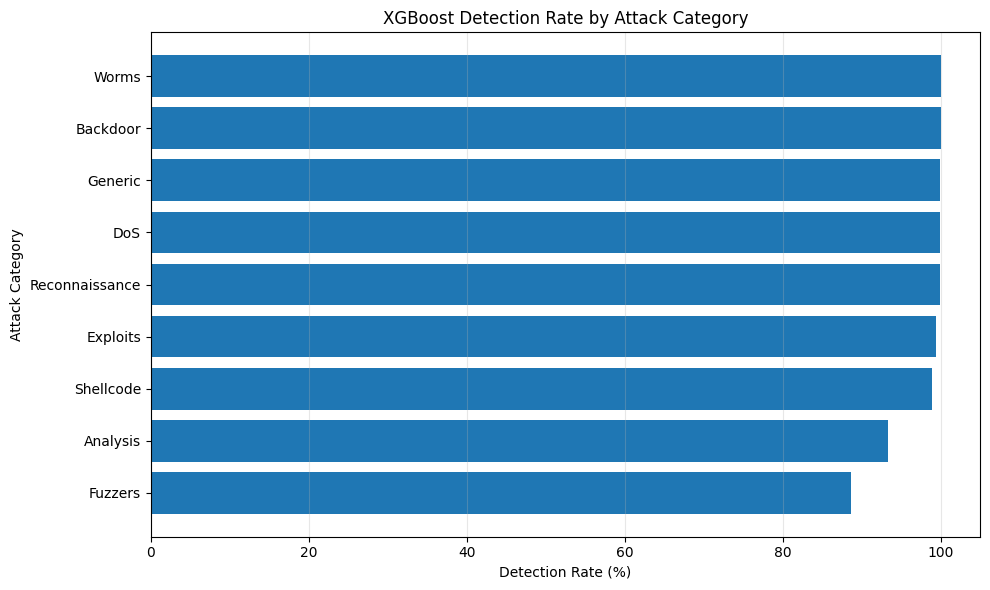

In [10]:
# Prepare data for plotting
plot_attack_detection = attack_detection.sort_values(
    "Detection_Rate",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_attack_detection.index,
    plot_attack_detection["Detection_Rate"]
)

plt.xlabel("Detection Rate (%)")
plt.ylabel("Attack Category")
plt.title("XGBoost Detection Rate by Attack Category")

plt.xlim(0, 105)
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

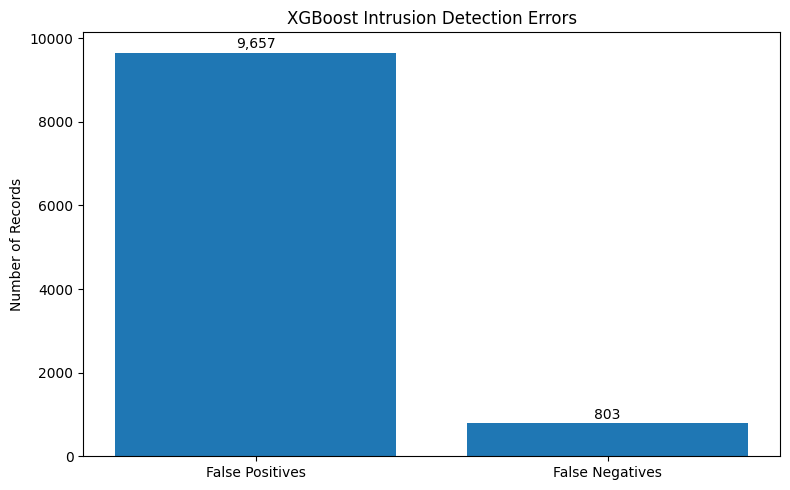

In [11]:
# Calculate confusion matrix values
tn, fp, fn, tp = cm.ravel()

error_types = ["False Positives", "False Negatives"]
error_counts = [fp, fn]

plt.figure(figsize=(8, 5))

plt.bar(
    error_types,
    error_counts
)

plt.ylabel("Number of Records")
plt.title("XGBoost Intrusion Detection Errors")

# Add count above each bar
for i, value in enumerate(error_counts):
    plt.text(
        i,
        value + 100,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

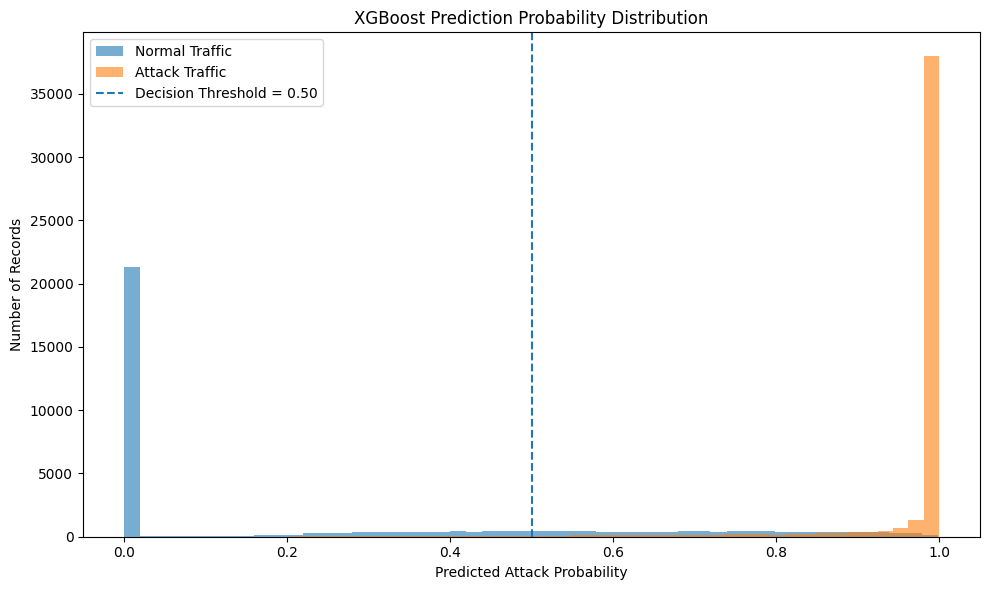

In [12]:
# Separate probabilities by actual class
normal_probabilities = final_prob[y_test == 0]
attack_probabilities = final_prob[y_test == 1]

plt.figure(figsize=(10, 6))

plt.hist(
    normal_probabilities,
    bins=50,
    alpha=0.6,
    label="Normal Traffic"
)

plt.hist(
    attack_probabilities,
    bins=50,
    alpha=0.6,
    label="Attack Traffic"
)

# Show decision threshold
plt.axvline(
    config["threshold"],
    linestyle="--",
    label="Decision Threshold = 0.50"
)

plt.xlabel("Predicted Attack Probability")
plt.ylabel("Number of Records")
plt.title("XGBoost Prediction Probability Distribution")

plt.legend()
plt.tight_layout()

plt.show()

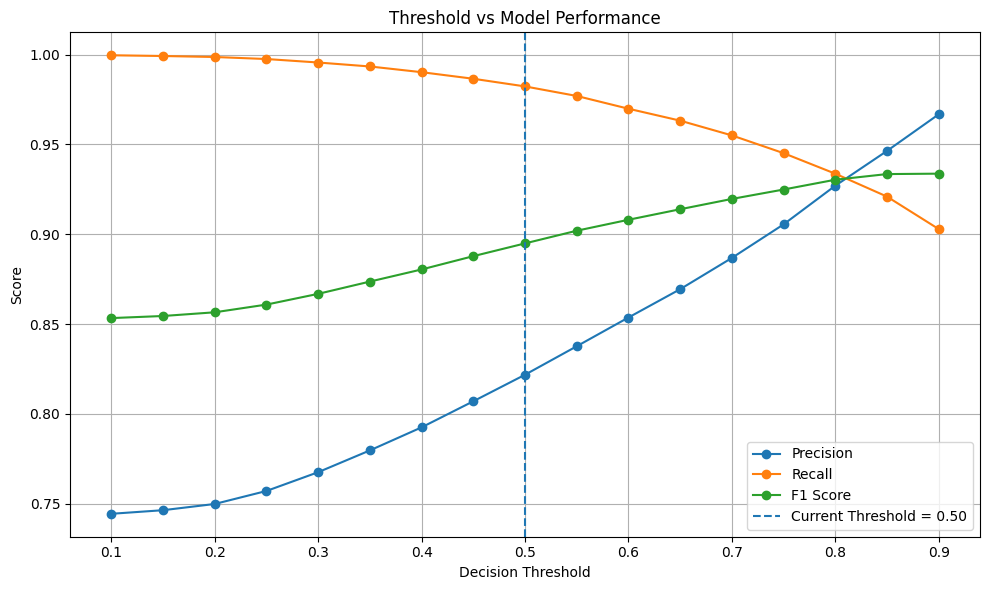

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_values = np.arange(0.10, 0.91, 0.05)

precision_values = []
recall_values = []
f1_values = []

for threshold in threshold_values:

    predictions = (
        final_prob >= threshold
    ).astype(int)

    precision_values.append(
        precision_score(y_test, predictions)
    )

    recall_values.append(
        recall_score(y_test, predictions)
    )

    f1_values.append(
        f1_score(y_test, predictions)
    )

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_values,
    precision_values,
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_values,
    recall_values,
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_values,
    f1_values,
    marker="o",
    label="F1 Score"
)

plt.axvline(
    config["threshold"],
    linestyle="--",
    label="Current Threshold = 0.50"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Model Performance")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [14]:
# Find threshold with the highest F1 score

best_index = np.argmax(f1_values)

best_threshold = threshold_values[best_index]
best_precision = precision_values[best_index]
best_recall = recall_values[best_index]
best_f1 = f1_values[best_index]

print("Best threshold based on F1 Score")
print("--------------------------------")
print("Threshold :", round(best_threshold, 2))
print("Precision :", round(best_precision, 4))
print("Recall    :", round(best_recall, 4))
print("F1 Score  :", round(best_f1, 4))

Best threshold based on F1 Score
--------------------------------
Threshold : 0.9
Precision : 0.9667
Recall    : 0.9029
F1 Score  : 0.9337


In [15]:
from sklearn.metrics import confusion_matrix

# Compare current threshold with best-F1 threshold
comparison_thresholds = [0.50, best_threshold]

for threshold in comparison_thresholds:

    predictions = (final_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    print(f"\nThreshold: {threshold:.2f}")
    print("-------------------------")
    print("True Negatives :", tn)
    print("False Positives:", fp)
    print("False Negatives:", fn)
    print("True Positives :", tp)


Threshold: 0.50
-------------------------
True Negatives : 27343
False Positives: 9657
False Negatives: 803
True Positives : 44529

Threshold: 0.90
-------------------------
True Negatives : 35591
False Positives: 1409
False Negatives: 4402
True Positives : 40930


In [16]:
# Compare security impact of thresholds

fp_reduction = 9657 - 1409
fn_increase = 4402 - 803

fp_reduction_percent = (
    fp_reduction / 9657
) * 100

fn_increase_percent = (
    fn_increase / 803
) * 100

print("THRESHOLD SECURITY TRADEOFF")
print("---------------------------")

print(
    "False positives reduced:",
    fp_reduction,
    f"({fp_reduction_percent:.2f}%)"
)

print(
    "Additional attacks missed:",
    fn_increase,
    f"({fn_increase_percent:.2f}%)"
)

THRESHOLD SECURITY TRADEOFF
---------------------------
False positives reduced: 8248 (85.41%)
Additional attacks missed: 3599 (448.19%)


In [17]:
threshold_comparison = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Precision",
        "Recall",
        "F1 Score",
        "False Positives",
        "False Negatives"
    ],
    "Current Threshold": [
        0.50,
        0.8218,
        0.9823,
        0.8949,
        9657,
        803
    ],
    "Best F1 Threshold": [
        0.90,
        0.9667,
        0.9029,
        0.9337,
        1409,
        4402
    ]
})

threshold_comparison

,Metric,Current Threshold,Best F1 Threshold
0,Threshold,0.5000,0.9000
1,Precision,0.8218,0.9667
2,Recall,0.9823,0.9029
3,F1 Score,0.8949,0.9337
4,False Positives,9657.0000,1409.0000
5,False Negatives,803.0000,4402.0000


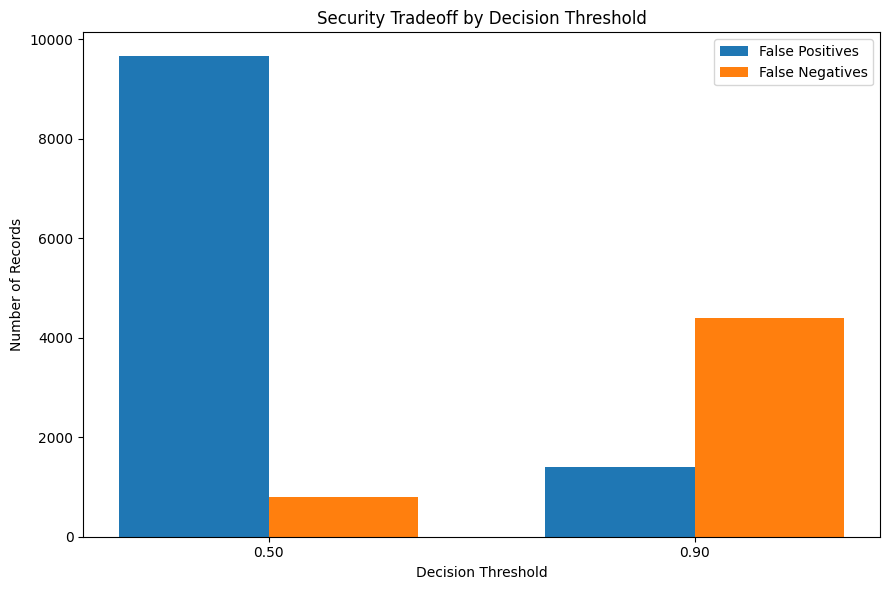

In [18]:
import matplotlib.pyplot as plt
import numpy as np

threshold_labels = ["0.50", "0.90"]

false_positives = [9657, 1409]
false_negatives = [803, 4402]

x = np.arange(len(threshold_labels))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    x - width/2,
    false_positives,
    width,
    label="False Positives"
)

plt.bar(
    x + width/2,
    false_negatives,
    width,
    label="False Negatives"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Number of Records")
plt.title("Security Tradeoff by Decision Threshold")

plt.xticks(x, threshold_labels)
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
print("=" * 65)
print("XGBOOST INTRUSION DETECTION - FINAL MODEL REPORT")
print("=" * 65)

print("\nDATASET")
print("Test records:", len(y_test))
print("Normal records:", (y_test == 0).sum())
print("Attack records:", (y_test == 1).sum())

print("\nMODEL PERFORMANCE")
print("Accuracy : 87.30%")
print("Precision: 82.18%")
print("Recall   : 98.23%")
print("F1 Score : 89.49%")
print("ROC-AUC  : 98.31%")

print("\nCONFUSION MATRIX")
print("True Negatives :", 27343)
print("False Positives:", 9657)
print("False Negatives:", 803)
print("True Positives :", 44529)

print("\nATTACK DETECTION")
print("Highest detection:")
print("  Backdoor: 100.00%")
print("  Worms:    100.00%")
print("  Generic:   99.99%")

print("\nLowest detection:")
print("  Fuzzers:   88.70%")
print("  Analysis:  93.35%")

print("\nTHRESHOLD ANALYSIS")
print("Threshold 0.50:")
print("  False positives: 9657")
print("  False negatives: 803")

print("\nThreshold 0.90:")
print("  False positives: 1409")
print("  False negatives: 4402")

print("\nSECURITY DECISION")
print(
    "Threshold 0.50 retained because intrusion detection "
    "prioritizes high attack recall and fewer missed attacks."
)

print("\n" + "=" * 65)

XGBOOST INTRUSION DETECTION - FINAL MODEL REPORT

DATASET
Test records: 82332
Normal records: 37000
Attack records: 45332

MODEL PERFORMANCE
Accuracy : 87.30%
Precision: 82.18%
Recall   : 98.23%
F1 Score : 89.49%
ROC-AUC  : 98.31%

CONFUSION MATRIX
True Negatives : 27343
False Positives: 9657
False Negatives: 803
True Positives : 44529

ATTACK DETECTION
Highest detection:
  Backdoor: 100.00%
  Worms:    100.00%
  Generic:   99.99%

Lowest detection:
  Fuzzers:   88.70%
  Analysis:  93.35%

THRESHOLD ANALYSIS
Threshold 0.50:
  False positives: 9657
  False negatives: 803

Threshold 0.90:
  False positives: 1409
  False negatives: 4402

SECURITY DECISION
Threshold 0.50 retained because intrusion detection prioritizes high attack recall and fewer missed attacks.



In [20]:
# Create final model results table

final_report = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives",
        "Decision Threshold"
    ],
    "Value": [
        0.8730,
        0.8218,
        0.9823,
        0.8949,
        0.9831,
        27343,
        9657,
        803,
        44529,
        0.50
    ]
})

# Save in the project models directory
report_path = models_dir / "final_model_report.csv"

final_report.to_csv(report_path, index=False)

print("Final model report saved successfully!")
print("Location:", report_path.resolve())

final_report

Final model report saved successfully!
Location: C:\Users\hsv89\cyber_ml_project\models\final_model_report.csv


,Metric,Value
0,Accuracy,0.8730
1,Precision,0.8218
2,Recall,0.9823
3,F1 Score,0.8949
4,ROC-AUC,0.9831
5,True Negatives,27343.0000
6,False Positives,9657.0000
7,False Negatives,803.0000
8,True Positives,44529.0000
9,Decision Threshold,0.5000
